# EEG-Based Epileptic Seizure Detection using Transfer Learning

This notebook implements a **Transfer Learning framework for automated epileptic seizure classification using EEG signals**.

The EEG signals are converted into **time–frequency spectrogram images**, which are then used to train a **ResNet50 deep learning model**.

### Objective
Classify EEG signals into three brain states:

- Healthy
- Ictal (during seizure)
- Interictal (between seizures)

### Dataset
Bonn University EEG Dataset

## Mount Google Drive

Since the spectrogram dataset is stored in Google Drive, we mount the drive to access the dataset within the Colab environment.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip


/content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip


## Extract Spectrogram Dataset

The spectrogram images generated from EEG signals are stored as a compressed `.zip` file.

This step extracts the dataset into the working directory for training.

In [3]:
!unzip "/content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip" -d /content/

Archive:  /content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip
   creating: /content/spectrogram_dataset/
   creating: /content/spectrogram_dataset/healthy/
   creating: /content/spectrogram_dataset/ictal/
   creating: /content/spectrogram_dataset/interictal/
  inflating: /content/spectrogram_dataset/healthy/Z099.png  
  inflating: /content/spectrogram_dataset/healthy/Z066.png  
  inflating: /content/spectrogram_dataset/healthy/O033.png  
  inflating: /content/spectrogram_dataset/healthy/O027.png  
  inflating: /content/spectrogram_dataset/healthy/Z072.png  
  inflating: /content/spectrogram_dataset/healthy/O026.png  
  inflating: /content/spectrogram_dataset/healthy/Z073.png  
  inflating: /content/spectrogram_dataset/healthy/Z067.png  
  inflating: /content/spectrogram_dataset/healthy/O032.png  
  inflating: /content/spectrogram_dataset/healthy/Z098.png  
  inflating: /content/spectrogram_dataset/healthy/Z071.png  
  inflating: /content/spectrogram_dataset/healthy/O024.png  
  

In [ ]:
!pip install tensorflow scikit-learn

## Import Required Libraries

This section imports the necessary libraries for:

- Deep Learning (TensorFlow / Keras)
- Image preprocessing
- Transfer learning models
- Evaluation metrics
- Data visualization

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 224
BATCH_SIZE = 16


In [ ]:
EPOCHS = 30

## Image Preprocessing and Data Augmentation

The spectrogram images are preprocessed before being fed to the neural network.

Key operations:

- ResNet50 preprocessing (`preprocess_input`)
- Data normalization
- Data augmentation (rotation, shift, zoom)

Data augmentation helps improve model generalization for small datasets.

In [6]:
import os
import random
import shutil

source = "/content/spectrogram_dataset"
target = "/content/eeg_dataset"

classes = ["healthy","ictal","interictal"]

train_ratio = 0.75
val_ratio = 0.15

# Create train/val/test directories first
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target, split, cls), exist_ok=True)

for cls in classes:

    files = os.listdir(os.path.join(source, cls))
    random.shuffle(files)

    total = len(files)

    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    for f in train_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(target, "train", cls, f)
        )

    for f in val_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(target, "val", cls, f)
        )

    for f in test_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(target, "test", cls, f)
        )

## Load Spectrogram Dataset

The dataset is loaded using `flow_from_directory()`.

Dataset structure:

spectrogram_dataset/

- healthy
- ictal
- interictal

The dataset is split into:

- **Training set (70%)**
- **Validation set (15%)**
- **Testing set (15%)**

Compute Mean & Std

In [35]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

temp_datagen = ImageDataGenerator(rescale=1./255)

temp_data = temp_datagen.flow_from_directory(
    "/content/eeg_dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

mean = 0.
std = 0.
total_images = 0

for i in range(len(temp_data)):
    batch = temp_data[i]
    mean += np.mean(batch, axis=(0,1,2))
    std += np.std(batch, axis=(0,1,2))
    total_images += 1

mean /= total_images
std /= total_images

print("Mean:", mean)
print("Std:", std)

Found 375 images belonging to 3 classes.
Mean: [0.23163886 0.5921696  0.48736835]
Std: [0.15155396 0.14649126 0.10500305]


Custom Normalizing Function

In [8]:
def normalize(img):
    img = img / 255.0
    return (img - mean) / (std + 1e-7)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=normalize,
    rotation_range=0,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=False
)

val_datagen = ImageDataGenerator(
    preprocessing_function=normalize
)

test_datagen = ImageDataGenerator(
    preprocessing_function=normalize
)

In [10]:
train_data = train_datagen.flow_from_directory(
    "/content/eeg_dataset/train",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    "/content/eeg_dataset/val",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    "/content/eeg_dataset/test",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

Found 375 images belonging to 3 classes.
Found 75 images belonging to 3 classes.
Found 50 images belonging to 3 classes.


## Load Pretrained ResNet50 Model

ResNet50 is a deep convolutional neural network pretrained on the **ImageNet dataset**.

Transfer learning allows the model to reuse learned feature representations and adapt them for EEG spectrogram classification.

The top classification layers are removed so that custom layers can be added.

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
#unfreeze the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
print("Train samples:", train_data.samples)
print("Validation samples:", val_data.samples)
print("Test samples:", test_data.samples)

Train samples: 375
Validation samples: 75
Test samples: 50


## Custom Classification Head

New layers are added on top of the pretrained ResNet50 base:

1. Global Average Pooling
2. Fully connected Dense layer
3. Softmax output layer

The output layer predicts **three classes**:
Healthy, Ictal, and Interictal.

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.5)(x)

x = Dense(256, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.3)(x)


output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation_8[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_11[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,986,275 (87.69 MB)

 Trainable params: 8,355,267 (31.87 MB)

 Non-trainable params: 14,631,008 (55.81 MB)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3813 - loss: 1.3217 - val_accuracy: 0.4133 - val_loss: 1.0437
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step - accuracy: 0.5547 - loss: 1.0066 - val_accuracy: 0.4800 - val_loss: 0.9866
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 346ms/step - accuracy: 0.5467 - loss: 0.9338 - val_accuracy: 0.5867 - val_loss: 0.9342
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - accuracy: 0.6453 - loss: 0.7992 - val_accuracy: 0.6400 - val_loss: 0.8755
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 257ms/step - accuracy: 0.7067 - loss: 0.7352 - val_accuracy: 0.7200 - val_loss: 0.8151
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 281ms/step - accuracy: 0.7227 - loss: 0.6804 - val_accuracy: 0.7600 - val_loss: 0.7594
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.7573 - loss: 0.6147 - val_accuracy: 0.7467 - val_loss: 0.7052
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 309ms/step - accuracy: 0.7813 - loss: 0.5751 - val_accuracy: 0.80

In [ ]:
model.save("eeg_resnet_model.h5")

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9600 - loss: 0.1285
Validation Accuracy: 0.9599999785423279


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(y_true, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
[[29  1  0]
 [ 0 14  1]
 [ 0  1 29]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.88      0.93      0.90        15
           2       0.97      0.97      0.97        30

    accuracy                           0.96        75
   macro avg       0.95      0.96      0.95        75
weighted avg       0.96      0.96      0.96        75



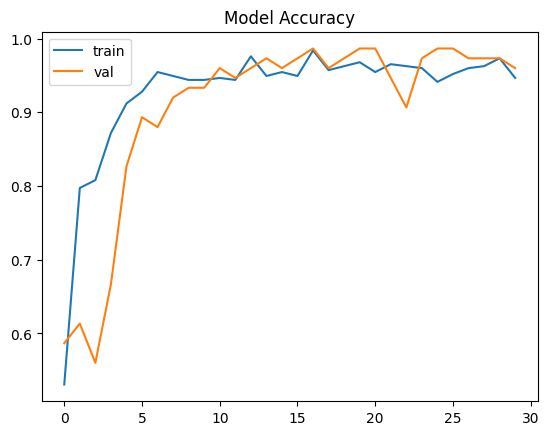

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Model Accuracy")
plt.show()

In [ ]:
# Evaluate model on test dataset
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 730ms/step - accuracy: 0.9800 - loss: 0.0931
Test Loss: 0.09305290132761002
Test Accuracy: 0.9800000190734863


In [ ]:

predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(y_true, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 950ms/step
[[18  0  2]
 [ 1  9  0]
 [ 0  0 20]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        20
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        20

    accuracy                           0.94        50
   macro avg       0.95      0.93      0.94        50
weighted avg       0.94      0.94      0.94        50



# **EfficientNet Model**

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation
base_model_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

#Compile (LOW LR)

In [ ]:
for layer in base_model_eff.layers:
    layer.trainable = False

In [ ]:
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.5)(x)

x = Dense(256, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.3)(x)

x = Dense(128, use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

output = Dense(3, activation="softmax")(x)

model_eff = Model(inputs=base_model_eff.input, outputs=output)

In [ ]:
model_eff.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.4240 - loss: 1.2111 - val_accuracy: 0.2000 - val_loss: 1.1177
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.4347 - loss: 1.1351 - val_accuracy: 0.4000 - val_loss: 1.0952
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.4613 - loss: 1.1085 - val_accuracy: 0.4000 - val_loss: 1.0786
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.4587 - loss: 1.1286 - val_accuracy: 0.4000 - val_loss: 1.0724
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.5147 - loss: 1.0926 - val_accuracy: 0.4000 - val_loss: 1.0732
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.4720 - loss: 1.1228 - val_accuracy: 0.4000 - val_loss: 1.0612
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.5200 - loss: 1.0331 - val_accuracy: 0.4000 - val_loss: 1.0595
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.4773 - loss: 1.0768 - val_accuracy: 0.40

#Fine-Tuning :Unfreeze last layers

In [ ]:
for layer in base_model_eff.layers:
    if "block6" in layer.name or "block7" in layer.name:
        layer.trainable = True

In [ ]:
model_eff.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history_eff_fine = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.3733 - loss: 1.2323 - val_accuracy: 0.6667 - val_loss: 0.9980
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - accuracy: 0.3467 - loss: 1.2969 - val_accuracy: 0.5333 - val_loss: 1.0194
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.4107 - loss: 1.1912 - val_accuracy: 0.4533 - val_loss: 1.0212
Epoch 4/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.4053 - loss: 1.2060 - val_accuracy: 0.5200 - val_loss: 1.0138
Epoch 5/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.3973 - loss: 1.2340 - val_accuracy: 0.4400 - val_loss: 1.0103
Epoch 6/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 281ms/step - accuracy: 0.3787 - loss: 1.2303 - val_accuracy: 0.4267 - val_loss: 1.0124
Epoch 7/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.4027 - loss: 1.2342 - val_accuracy: 0.4000 - val_loss: 1.0172
Epoch 8/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.4000 - loss: 1.1981 - val_accuracy: 0.40

In [ ]:
loss, accuracy = model_eff.evaluate(val_data)

print("Validation Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6533 - loss: 0.9271
Validation Accuracy: 0.653333306312561


In [ ]:
# Evaluate model on test dataset
test_loss_eff, test_accuracy_eff = model_eff.evaluate(test_data)

print("Test Loss:", test_loss_eff)
print("Test Accuracy:", test_accuracy_eff)

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.6800 - loss: 0.8569
Test Loss: 0.8569027781486511
Test Accuracy: 0.6800000071525574


In [ ]:

predictions = model_eff.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(y_true, y_pred))

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step
[[17  0  3]
 [ 4  1  5]
 [ 4  0 16]]
              precision    recall  f1-score   support

           0       0.68      0.85      0.76        20
           1       1.00      0.10      0.18        10
           2       0.67      0.80      0.73        20

    accuracy                           0.68        50
   macro avg       0.78      0.58      0.55        50
weighted avg       0.74      0.68      0.63        50



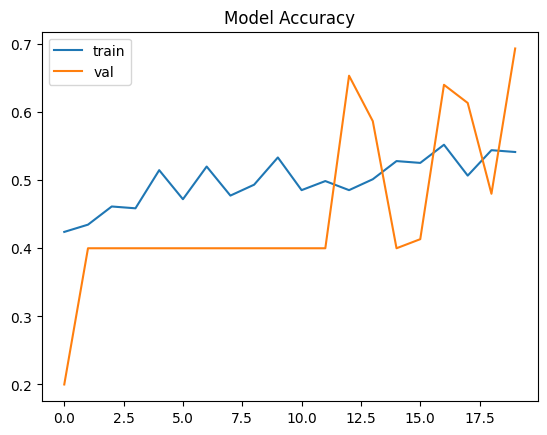

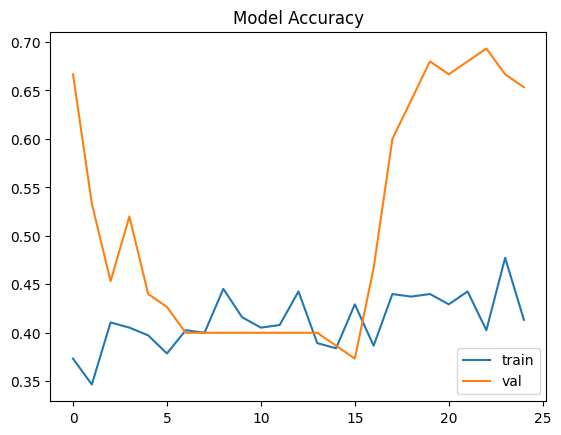

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_eff.history['accuracy'])
plt.plot(history_eff.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Model Accuracy")
plt.show()
plt.plot(history_eff_fine.history['accuracy'])
plt.plot(history_eff_fine.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Model Accuracy")
plt.show()

#Save the model

In [ ]:
model.save("efficientnet_eeg.keras")

This model fails predicting EEG dataset

# **GOOGLENET**

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(3, activation='softmax')(x)

model_inception = Model(inputs=base_model.input, outputs=output)

# Compile
model_inception.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model_inception.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4587 - loss: 1.3713 - val_accuracy: 0.5733 - val_loss: 0.9088
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.5893 - loss: 0.9986 - val_accuracy: 0.6667 - val_loss: 0.7989
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 0.6773 - loss: 0.8656 - val_accuracy: 0.7600 - val_loss: 0.7131
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 338ms/step - accuracy: 0.7067 - loss: 0.7216 - val_accuracy: 0.7867 - val_loss: 0.6332
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.7627 - loss: 0.6164 - val_accuracy: 0.8133 - val_loss: 0.5627
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 304ms/step - accuracy: 0.7467 - loss: 0.6142 - val_accuracy: 0.8267 - val_loss: 0.5374
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - accuracy: 0.7600 - loss: 0.5778 - val_accuracy: 0.8667 - val_loss: 0.4528
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 267ms/step - a

Fine Tuning

In [ ]:
# Unfreeze top layers only
for layer in base_model.layers[-50:]:
    layer.trainable = True

model_inception.compile(
    optimizer=Adam(learning_rate=1e-5),  # LOWER LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model_inception.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.6960 - loss: 0.7074 - val_accuracy: 0.8667 - val_loss: 0.3266
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.7040 - loss: 0.6751 - val_accuracy: 0.8667 - val_loss: 0.3255
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 0.7813 - loss: 0.6036 - val_accuracy: 0.8267 - val_loss: 0.3357
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 305ms/step - accuracy: 0.7600 - loss: 0.5965 - val_accuracy: 0.8400 - val_loss: 0.3462
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - accuracy: 0.7867 - loss: 0.5491 - val_accuracy: 0.8533 - val_loss: 0.3554
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step - accuracy: 0.7787 - loss: 0.5228 - val_accuracy: 0.8533 - val_loss: 0.3576
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step - accuracy: 0.7680 - loss: 0.6010 - val_accuracy: 0.8533 - val_loss: 0.3534
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.8053 - loss: 0.4804 - val_accuracy: 0.86

In [ ]:
# Evaluate model on test dataset
test_loss_eff, test_accuracy_eff = model_inception.evaluate(test_data)

print("Test Loss:", test_loss_eff)
print("Test Accuracy:", test_accuracy_eff)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8400 - loss: 0.3203
Test Loss: 0.32028090953826904
Test Accuracy: 0.8399999737739563


In [ ]:

predictions = model_inception.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(y_true, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step
[[17  0  3]
 [ 1  6  3]
 [ 0  1 19]]
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.86      0.60      0.71        10
           2       0.76      0.95      0.84        20

    accuracy                           0.84        50
   macro avg       0.85      0.80      0.82        50
weighted avg       0.85      0.84      0.84        50



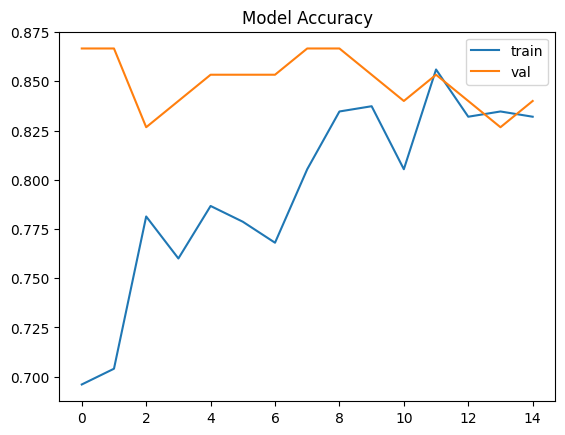

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Model Accuracy")
plt.show()


## Verify Class Label Mapping

The `class_indices` output confirms how folder names are mapped to numerical labels.

Example mapping:

- healthy → 0
- ictal → 1
- interictal → 2

In [ ]:
print(train_data.class_indices)

{'healthy': 0, 'ictal': 1, 'interictal': 2}


#**Custom CNN Architecture**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

model_cnn = Sequential()

model_cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D())

model_cnn.add(Conv2D(64, (3,3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D())

model_cnn.add(Conv2D(128, (3,3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D())

model_cnn.add(GlobalAveragePooling2D())

model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(Dropout(0.5))

model_cnn.add(Dense(3, activation='softmax'))

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 609ms/step - accuracy: 0.5360 - loss: 0.9231 - val_accuracy: 0.3200 - val_loss: 1.0931
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.6693 - loss: 0.7471 - val_accuracy: 0.2933 - val_loss: 1.0908
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.7093 - loss: 0.6598 - val_accuracy: 0.3200 - val_loss: 1.0848
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step - accuracy: 0.7120 - loss: 0.6566 - val_accuracy: 0.2400 - val_loss: 1.0873
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.7707 - loss: 0.6149 - val_accuracy: 0.2000 - val_loss: 1.0970
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 298ms/step - accuracy: 0.7787 - loss: 0.5552 - val_accuracy: 0.2000 - val_loss: 1.1093
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step - accuracy: 0.7707 - loss: 0.5795 - val_accuracy: 0.2000 - val_loss: 1.1209
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.7973 - loss: 0.5228 - val_accuracy: 0

In [ ]:
# Evaluate model on test dataset
test_loss_eff, test_accuracy_eff = model_cnn.evaluate(test_data)

print("Test Loss:", test_loss_eff)
print("Test Accuracy:", test_accuracy_eff)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step - accuracy: 0.9000 - loss: 0.4429
Test Loss: 0.44287100434303284
Test Accuracy: 0.8999999761581421


In [ ]:

predictions = model_cnn.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(y_true, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step
[[19  0  1]
 [ 0  7  3]
 [ 0  1 19]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.88      0.70      0.78        10
           2       0.83      0.95      0.88        20

    accuracy                           0.90        50
   macro avg       0.90      0.87      0.88        50
weighted avg       0.91      0.90      0.90        50



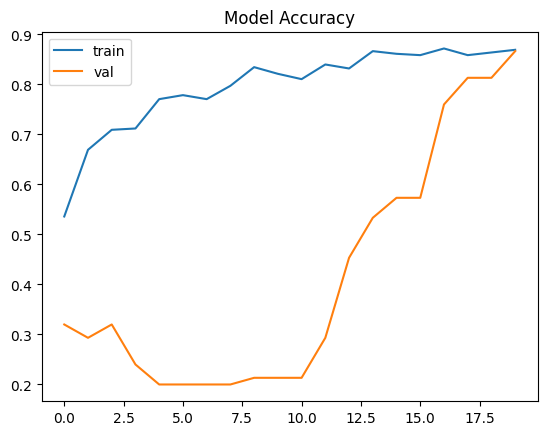

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Model Accuracy")
plt.show()


Comparing all the models on basis of:

| Metric            | Focus                                          |
| ----------------- | ---------------------------------------------- |
| Accuracy          | Overall correctness                            |
| F1-score          | Balanced performance                           |
| Class-wise recall | Performance per class (very important for EEG) |



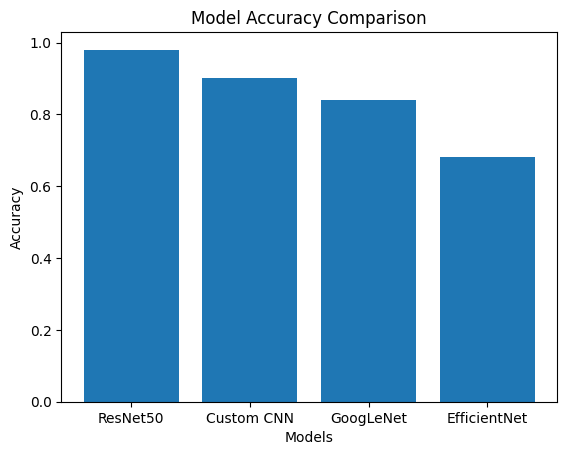

In [1]:
import matplotlib.pyplot as plt

models = ['ResNet50', 'Custom CNN', 'GoogLeNet', 'EfficientNet']
accuracy = [0.98, 0.90, 0.84, 0.68]

plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

Resnet Model wins

F1-score combines: Precision (correctness) and Recall (coverage)
F1-score tells how good a model is at both being correct and not missing cases

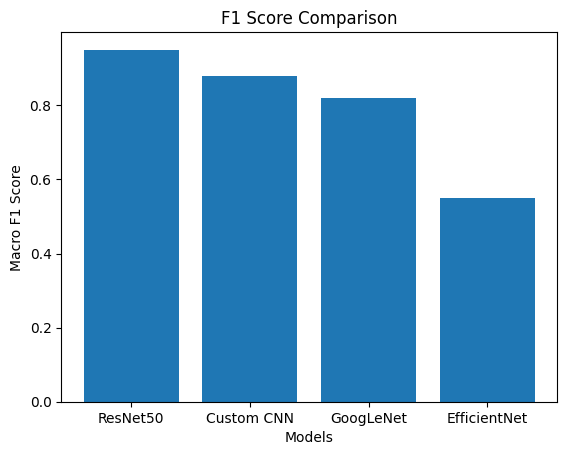

In [3]:
f1_scores = [0.95, 0.88, 0.82, 0.55]

plt.figure()
plt.bar(models, f1_scores)
plt.xlabel("Models")
plt.ylabel("Macro F1 Score")
plt.title("F1 Score Comparison")
plt.show()

Resnet wins

Class-wise recall means: how well the model correctly detects each individual class.

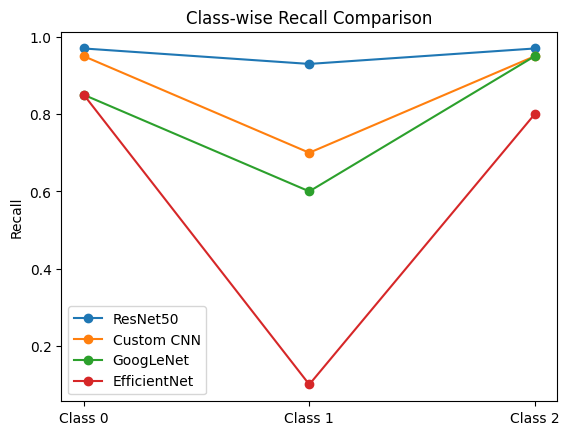

In [2]:
import numpy as np

recall = [
    [0.97, 0.93, 0.97],  # ResNet
    [0.95, 0.70, 0.95],  # CNN
    [0.85, 0.60, 0.95],  # GoogLeNet
    [0.85, 0.10, 0.80]   # EfficientNet
]

labels = ['Class 0', 'Class 1', 'Class 2']
x = np.arange(len(labels))

for i in range(len(models)):
    plt.plot(labels, recall[i], marker='o', label=models[i])

plt.legend()
plt.title("Class-wise Recall Comparison")
plt.ylabel("Recall")
plt.show()

| Model        | Class 0 | Class 1 | Class 2 | Overall view                    |
| ------------ | ------- | ------- | ------- | ------------------------------- |
| ResNet       | 0.97    | 0.93    | 0.97    | Best overall                    |
| CNN          | 0.95    | 0.70    | 0.95    | Good but weak seizure detection |
| GoogLeNet    | 0.85    | 0.60    | 0.95    | Moderate                        |
| EfficientNet | 0.85    | 0.10    | 0.80    | Worst                           |


#**XAI- Explainable AI**

In [12]:
from tensorflow.keras.models import load_model

# load the trained Model
saved_model = load_model("eeg_resnet_model(98%).h5")

# Grad-CAM for EEG Classification

 Using trained CNN (ResNet-based) model to classify EEG spectrogram images into Healthy, Ictal, and Interictal classes. It applies Grad-CAM to visualize which regions of the image influence the model’s prediction and overlays a heatmap on the original image for interpretability.

Using last conv layer: conv5_block3_out
Prediction probabilities: [0.00127241 0.02586703 0.9728606 ]
Predicted class: interictal


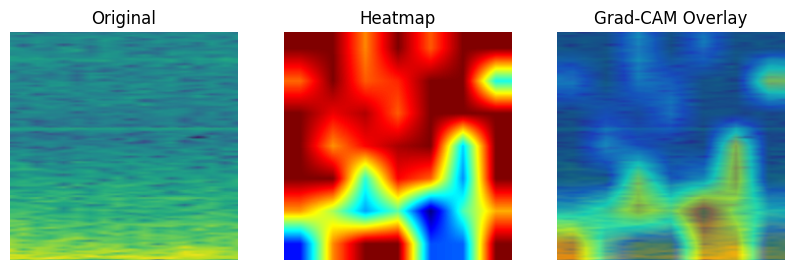

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
# =========================
# 1. LOAD TRAINED MODEL
# =========================
trained_model = tf.keras.models.load_model("eeg_resnet_model(98%).h5")

# =========================
# 2. CLASS NAMES
# =========================
class_names = ["healthy", "ictal", "interictal"]

# =========================
# 3. LOAD IMAGE
# =========================
def normalize(img):
    img = img.astype(np.float32) / 255.0
    return (img - mean) / (std + 1e-7)

def load_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = normalize(img_array)   
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# =========================
# 4. AUTO FIND LAST CONV LAYER
# =========================
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if "conv" in layer.name:
            return layer.name
    raise ValueError("No Conv layer found")

last_conv_layer_name = get_last_conv_layer(trained_model)
print("Using last conv layer:", last_conv_layer_name)

# =========================
# 5. GRAD-CAM FUNCTION
# =========================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Create a model that outputs:
    # 1. Feature maps from the last conv layer 2. Final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Record operations for gradient computation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # Get index of predicted class
        class_idx = tf.argmax(predictions[0])

        # Extract the score for that class
        loss = predictions[:, class_idx]

    # Compute gradients of the class score w.r.t. conv layer outputs
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling:Get importance weight for each feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    # Remove batch dimension (we only passed one image)
    conv_outputs = conv_outputs[0]

    # Multiply each channel in feature map by its importance weight and Then sum them → produces the raw heatmap
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)  # remove extra dimensions

    # Apply ReLU → keep only positive contributions
    heatmap = tf.maximum(heatmap, 0)

    # Normalize to range [0,1] for visualization
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy(), class_idx, predictions.numpy()

# =========================
# 6. DISPLAY FUNCTION
# =========================

def display_gradcam(img_path, heatmap, alpha=0.4):

    # Read original image (OpenCV reads in BGR format)
    img = cv2.imread(img_path)

    # Resize to match model input size
    img = cv2.resize(img, (224,224))

    # Resize heatmap to match image
    heatmap = cv2.resize(heatmap, (224,224))

    # Convert heatmap from [0,1] → [0,255]
    heatmap = np.uint8(255 * heatmap)

    # Apply color map (JET: blue → red)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on image
    # img weight = 0.6, heatmap weight = alpha
    superimposed = cv2.addWeighted(img, 0.6, heatmap, alpha, 0)

    # Create figure for visualization
    plt.figure(figsize=(10,4))

    # Show original image
    plt.subplot(1,3,1)
    plt.title("Original")
    # Convert BGR → RGB for correct display in matplotlib
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Show heatmap alone
    plt.subplot(1,3,2)
    plt.title("Heatmap")
    plt.imshow(heatmap)
    plt.axis('off')

    # Show overlay (Grad-CAM result)
    plt.subplot(1,3,3)
    plt.title("Grad-CAM Overlay")
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Display all plots
    plt.show()
# =========================
# 7. RUN ON IMAGE
# =========================
img_path = "/content/spectrogram_dataset/interictal/F001.png"  # change path

img_array = load_image(img_path)

heatmap, class_idx, predictions = make_gradcam_heatmap(
    img_array,
    trained_model,
    last_conv_layer_name
)

# =========================
# 8. PRINT RESULTS
# =========================
print("Prediction probabilities:", predictions[0])
print("Predicted class:", class_names[class_idx])

# =========================
# 9. DISPLAY
# =========================
display_gradcam(img_path, heatmap)

# Image prediction check

In [41]:
#class_names = ["healthy", "ictal", "interictal"]
for path in [
    "/content/spectrogram_dataset/healthy/O001.png",
    "/content/spectrogram_dataset/ictal/S001.png",
    "/content/spectrogram_dataset/interictal/F001.png"
]:
    img = load_image(path)
    pred = trained_model.predict(img)
    print(path, pred, np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
/content/spectrogram_dataset/healthy/O001.png [[0.94154745 0.03263837 0.02581418]] 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
/content/spectrogram_dataset/ictal/S001.png [[8.931943e-08 9.999999e-01 3.919881e-09]] 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
/content/spectrogram_dataset/interictal/F001.png [[0.00127244 0.02586761 0.97285986]] 2


#  Predictions for different classes


Image: /content/spectrogram_dataset/healthy/O028.png
Prediction probabilities: [0.98075473 0.0161843  0.00306091]
Predicted class: healthy


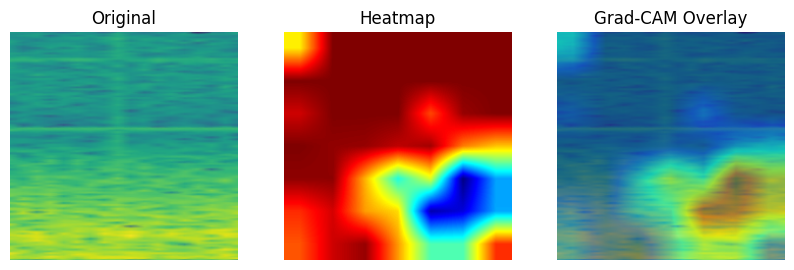


Image: /content/spectrogram_dataset/ictal/S044.png
Prediction probabilities: [1.7844523e-07 9.9999928e-01 6.5008658e-07]
Predicted class: ictal


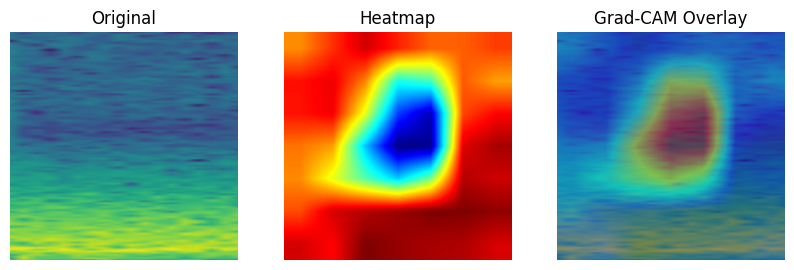


Image: /content/spectrogram_dataset/interictal/F021.png
Prediction probabilities: [0.00100973 0.00402346 0.9949668 ]
Predicted class: interictal


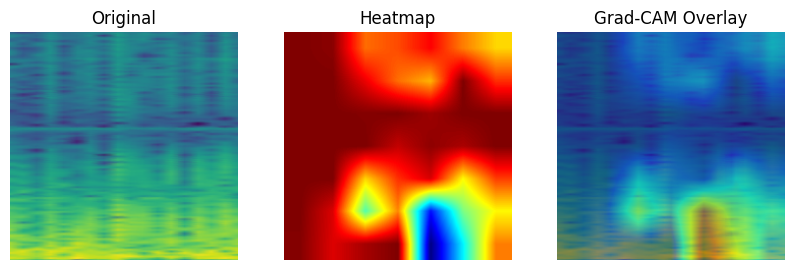

In [42]:
for path in [
    "/content/spectrogram_dataset/healthy/O028.png",
    "/content/spectrogram_dataset/ictal/S044.png",
    "/content/spectrogram_dataset/interictal/F021.png"
]:
    print("\n==============================")
    print("Image:", path)

    img_array = load_image(path)

    heatmap, class_idx, predictions = make_gradcam_heatmap(
        img_array,
        trained_model,
        last_conv_layer_name
    )

    print("Prediction probabilities:", predictions[0])
    print("Predicted class:", class_names[int(class_idx)])

    display_gradcam(path, heatmap)


# **COMPLETE RESULTS & EVALUATION PIPELINE**



✅ Dataset Loaded: (500, 224, 224, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step

🎯 Overall Accuracy: 0.986


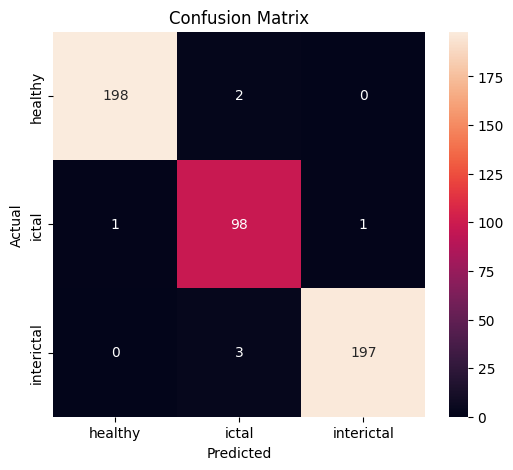


📋 Classification Report:

              precision    recall  f1-score   support

     healthy       0.99      0.99      0.99       200
       ictal       0.95      0.98      0.97       100
  interictal       0.99      0.98      0.99       200

    accuracy                           0.99       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.99      0.99      0.99       500


📊 Per-Class Accuracy:
healthy: 0.9900
ictal: 0.9800
interictal: 0.9850

❌ Total Wrong Predictions: 7

--- WRONG SAMPLE ---
Actual: healthy
Predicted: ictal


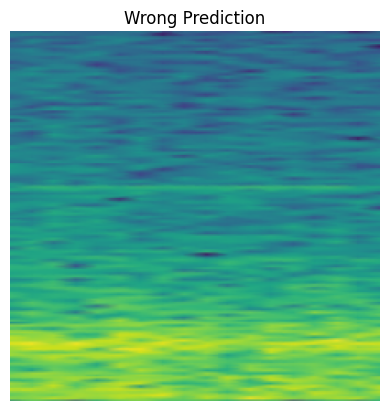


--- WRONG SAMPLE ---
Actual: healthy
Predicted: ictal


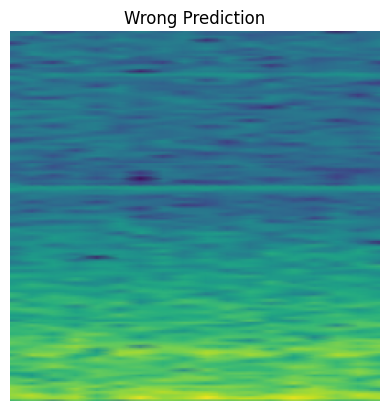


--- WRONG SAMPLE ---
Actual: ictal
Predicted: interictal


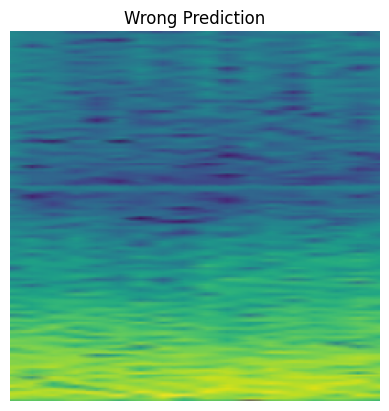


--- WRONG SAMPLE ---
Actual: ictal
Predicted: healthy


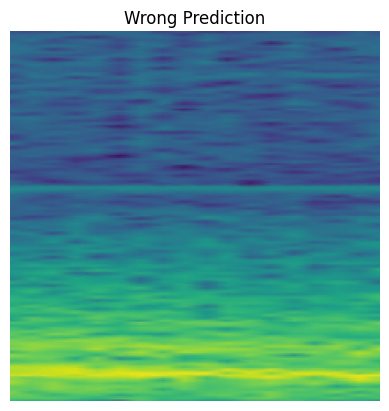


--- WRONG SAMPLE ---
Actual: interictal
Predicted: ictal


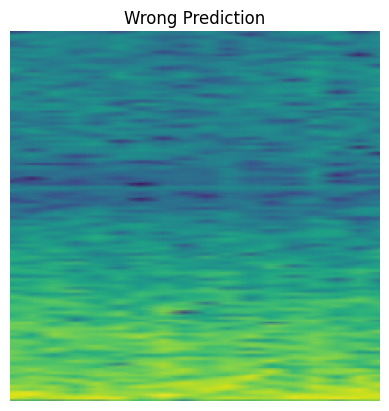


Image: /content/spectrogram_dataset/interictal/N082.png
Prediction: interictal
Probabilities: [0.00257426 0.05935091 0.93807477]


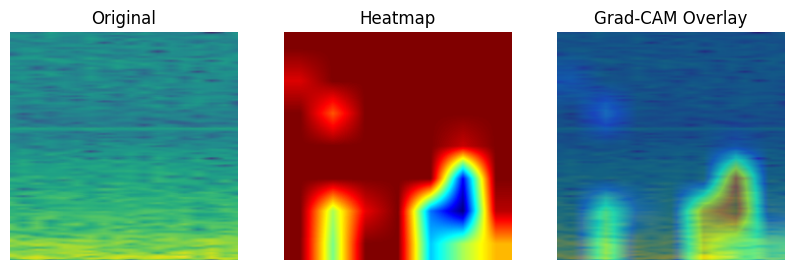


Image: /content/spectrogram_dataset/interictal/N091.png
Prediction: interictal
Probabilities: [0.01616922 0.35233286 0.6314979 ]


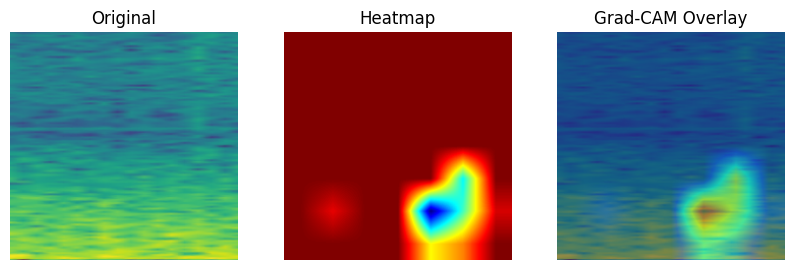


Image: /content/spectrogram_dataset/healthy/Z021.png
Prediction: healthy
Probabilities: [0.9727842  0.01542345 0.01179236]


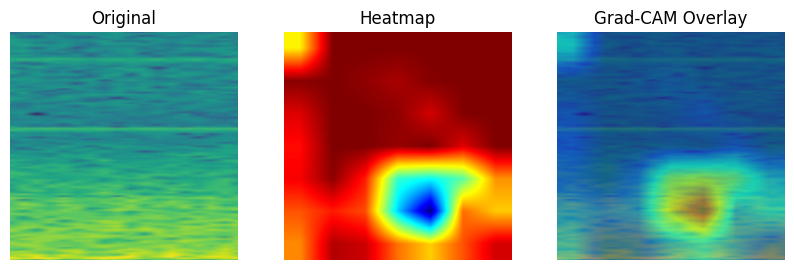


Image: /content/spectrogram_dataset/ictal/S023.png
Prediction: ictal
Probabilities: [1.3583083e-05 9.9998343e-01 3.0233477e-06]


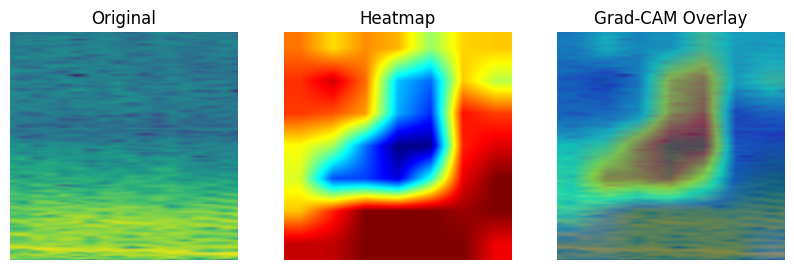


Image: /content/spectrogram_dataset/interictal/F063.png
Prediction: interictal
Probabilities: [1.01275764e-04 9.64998174e-03 9.90248740e-01]


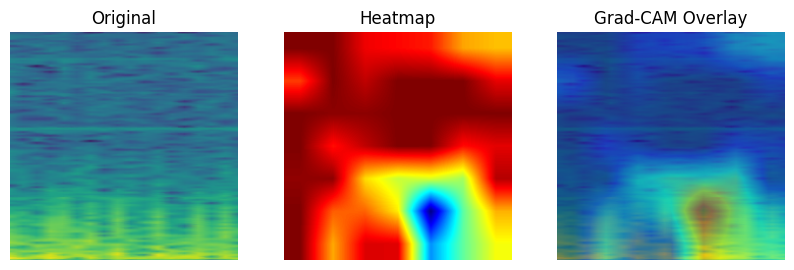


Image: /content/spectrogram_dataset/healthy/Z042.png
Prediction: healthy
Probabilities: [9.956650e-01 4.187804e-03 1.471385e-04]


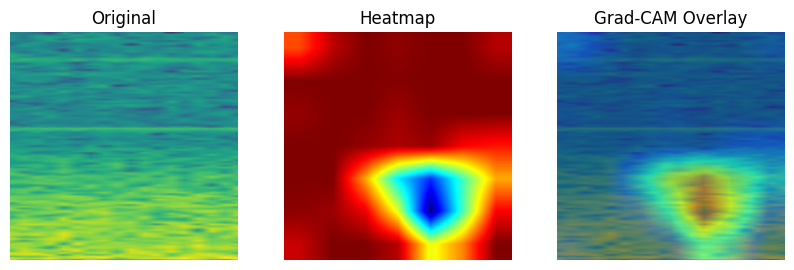

In [44]:

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ============================================================
# DEFINE NORMALIZATION
# ============================================================
mean = np.array([0.23163886, 0.5921696, 0.48736835], dtype=np.float32)
std  = np.array([0.15155396, 0.14649126, 0.10500305], dtype=np.float32)

# ============================================================
# 1. LOAD FULL DATASET
# ============================================================
def load_dataset(dataset_path):
    X, y, paths = [], [], []

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = normalize(img_array)

            X.append(img_array)
            y.append(label)
            paths.append(img_path)

    return np.array(X), np.array(y), paths

dataset_path = "/content/spectrogram_dataset"
X, y_true, img_paths = load_dataset(dataset_path)

print("✅ Dataset Loaded:", X.shape)

# ============================================================
# 2. MODEL PREDICTIONS
# ============================================================
y_pred_probs = saved_model.predict(X)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# 3. OVERALL ACCURACY
# ============================================================
acc = accuracy_score(y_true, y_pred)
print("\n🎯 Overall Accuracy:", acc)

# ============================================================
# 4. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================
print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
#  6. PER-CLASS ACCURACY
# ============================================================
print("\n📊 Per-Class Accuracy:")
for i, class_name in enumerate(class_names):
    indices = np.where(y_true == i)[0]
    class_acc = np.mean(y_pred[indices] == i)
    print(f"{class_name}: {class_acc:.4f}")

# ============================================================
#  7. WRONG PREDICTIONS (VERY IMPORTANT)
# ============================================================
wrong_indices = np.where(y_true != y_pred)[0]
print("\n❌ Total Wrong Predictions:", len(wrong_indices))

for i in wrong_indices[:5]:  # show first 5 errors
    print("\n--- WRONG SAMPLE ---")
    print("Actual:", class_names[y_true[i]])
    print("Predicted:", class_names[y_pred[i]])

    img = X[i]
    img = (img * std) + mean  # reverse normalization

    plt.imshow(img)
    plt.title("Wrong Prediction")
    plt.axis('off')
    plt.show()

# ============================================================
#  8. MULTIPLE GRAD-CAM VISUALIZATION
# ============================================================
def show_multiple_gradcam(dataset_path, num_samples=6):

    all_paths = []


    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            all_paths.append(os.path.join(class_path, img_name))

    samples = random.sample(all_paths, num_samples)

    for path in samples:
        print("\n==============================")
        print("Image:", path)

        img_array = load_image(path)

        heatmap, class_idx, predictions = make_gradcam_heatmap(
            img_array,
            trained_model,
            last_conv_layer_name
        )

        print("Prediction:", class_names[int(class_idx)])
        print("Probabilities:", predictions[0])

        display_gradcam(path, heatmap)

# 👉 Run Grad-CAM on random samples
show_multiple_gradcam(dataset_path)
